# Part1

# Task1

In [2]:
import pandas as pd

df = pd.read_csv('C:/Users/kumar/OneDrive/Desktop/TRY-2/Tasks-Submission/Assignment12/student_data.csv')

# Print shape
print("Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# First 5 rows
df.head()


Shape: (395, 33)

Columns:
 Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


# Task2

In [3]:
import json

data = [
    {"id": 1, "product": "Laptop", "price": 50000},
    {"id": 2, "product": "Phone", "price": 25000},
    {"id": 3, "product": "Tablet", "price": 30000}
]

with open("products.json", "w") as f:
    json.dump(data, f)

df_json = pd.read_json("products.json")
df_json


,id,product,price
0,1,Laptop,50000
1,2,Phone,25000
2,3,Tablet,30000


# Task3

In [4]:
import sqlite3

conn = sqlite3.connect("company.db")
cur = conn.cursor()

cur.execute("""
CREATE TABLE employees(
    id INTEGER,
    name TEXT,
    department TEXT,
    salary INTEGER
)
""")

cur.executemany("INSERT INTO employees VALUES (?, ?, ?, ?)", [
    (1,"Amit","HR",30000),
    (2,"Riya","IT",50000),
    (3,"Kunal","Sales",40000),
    (4,"Neha","IT",60000),
    (5,"Rahul","HR",35000)
])

conn.commit()

df_sql = pd.read_sql("SELECT * FROM employees", conn)
df_sql


,id,name,department,salary
0,1,Amit,HR,30000
1,2,Riya,IT,50000
2,3,Kunal,Sales,40000
3,4,Neha,IT,60000
4,5,Rahul,HR,35000


# Task4

In [5]:
import requests

API_KEY 

res = requests.get(url).json()

movies = []
for m in res["results"]:
    movies.append({
        "title": m["title"],
        "release_date": m["release_date"],
        "rating": m["vote_average"],
        "popularity": m["popularity"]
    })

df_movies = pd.DataFrame(movies)
df_movies.to_csv("tmdb_movies.csv", index=False)

df_movies.head()


NameError: name 'API_KEY' is not defined

# Part2

# Task5

In [6]:
df.shape
df.dtypes

num_cols = df.select_dtypes(include=["int64","float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

df.isnull().sum()


school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

# Task6

In [7]:
# Fill missing values
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Rename columns
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Fix datatypes
df["age"] = df["age"].astype(int)


C:\Windows\Temp\ipykernel_13336\3795819605.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Windows\Temp\ipykernel_13336\3795819605.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

# Task7

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])

X = df.drop("absences", axis=1)
y = df["health"]


# Part3

# Task8

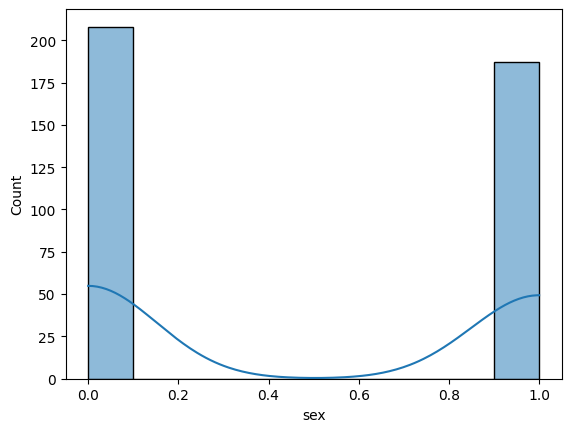

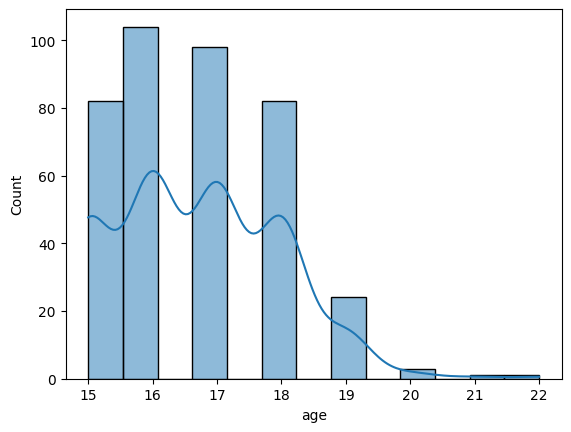

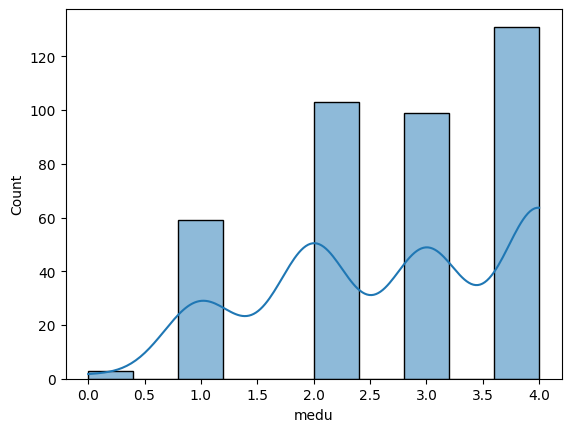

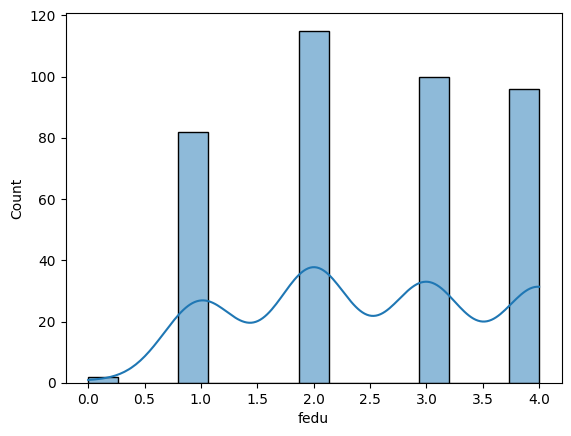

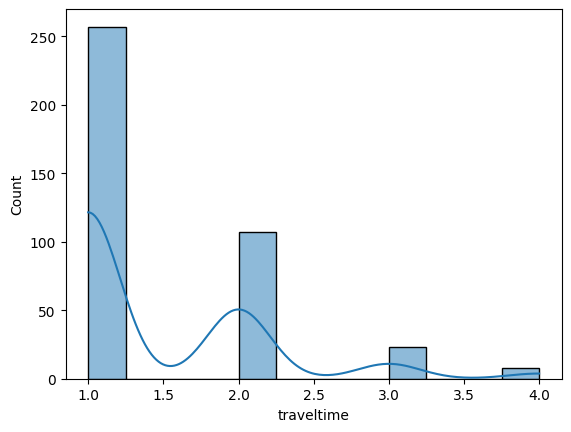

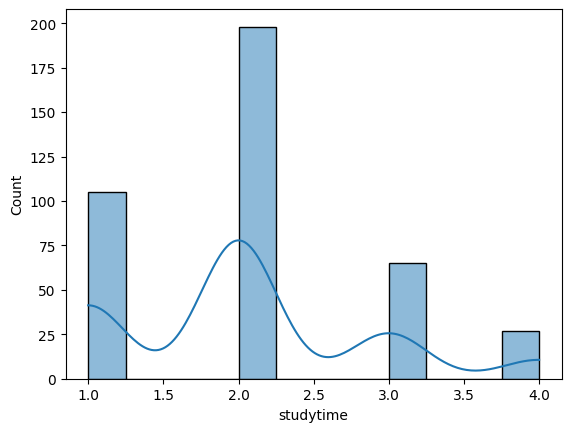

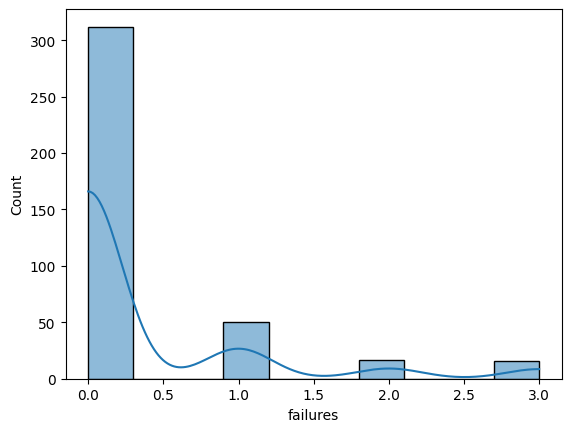

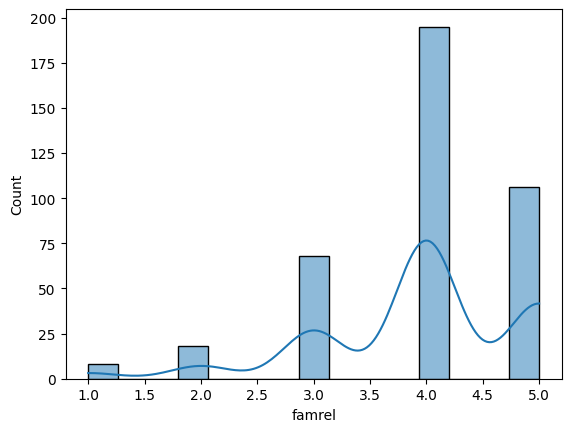

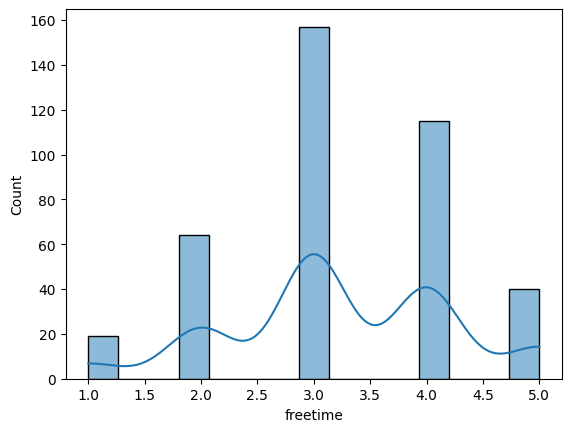

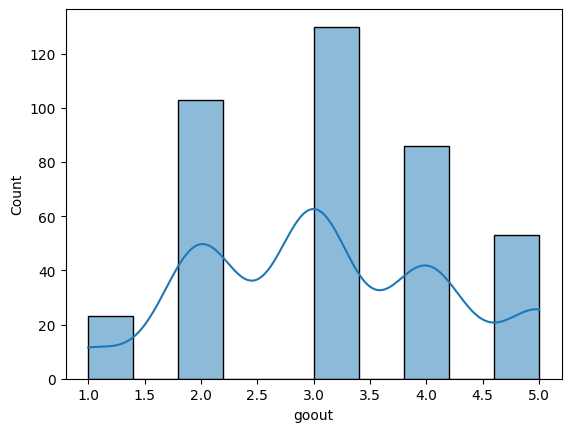

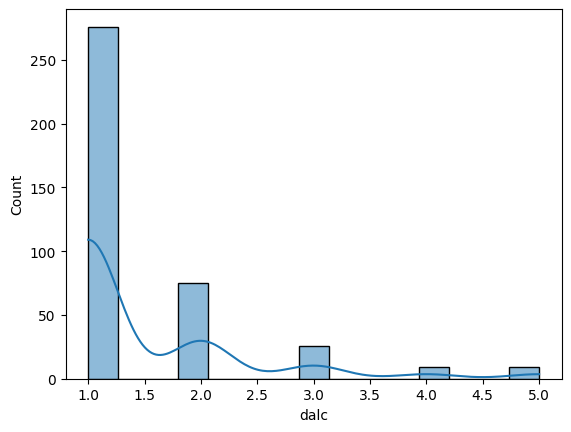

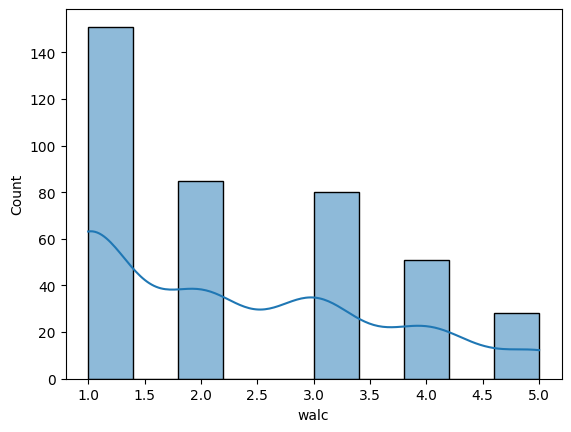

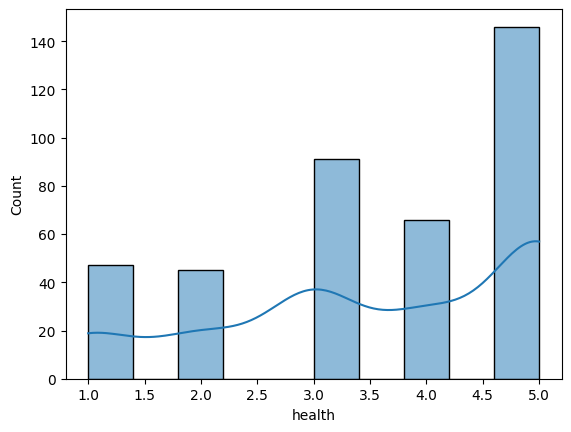

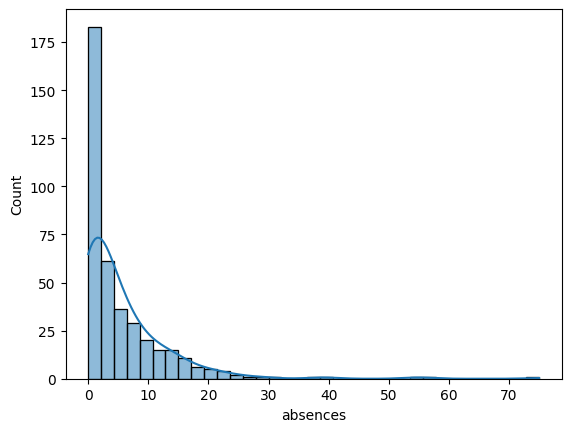

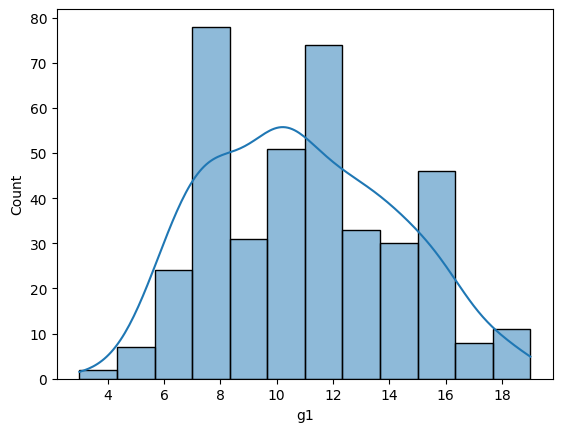

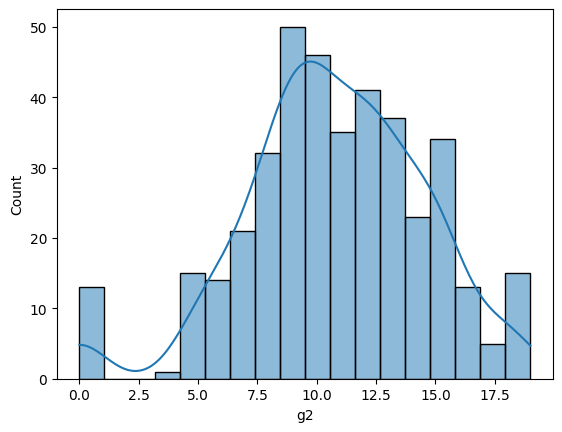

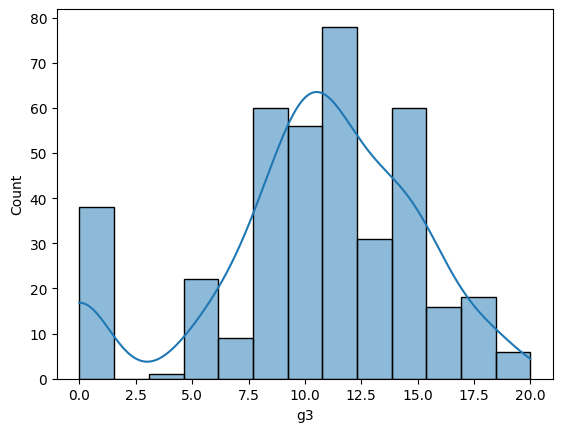

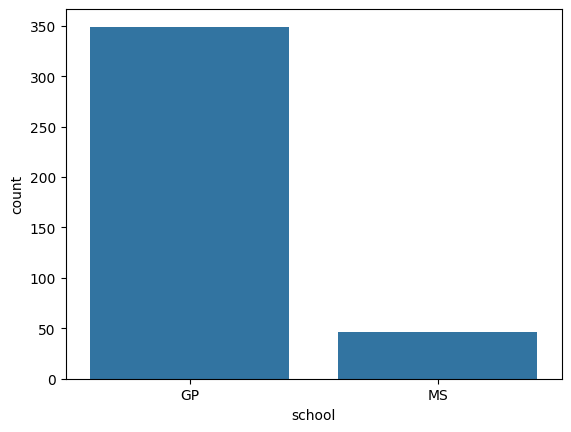

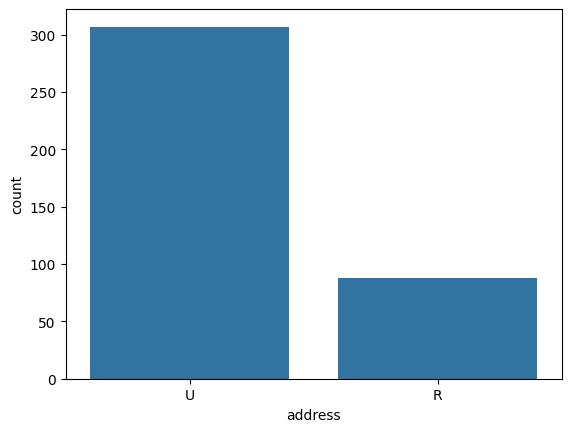

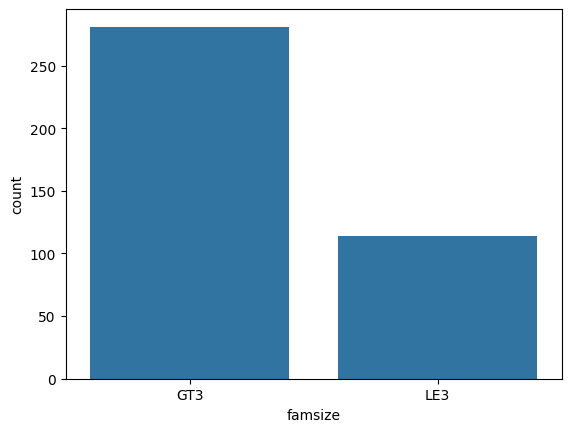

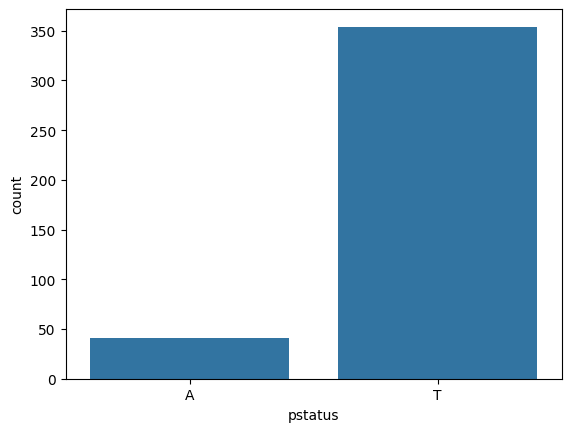

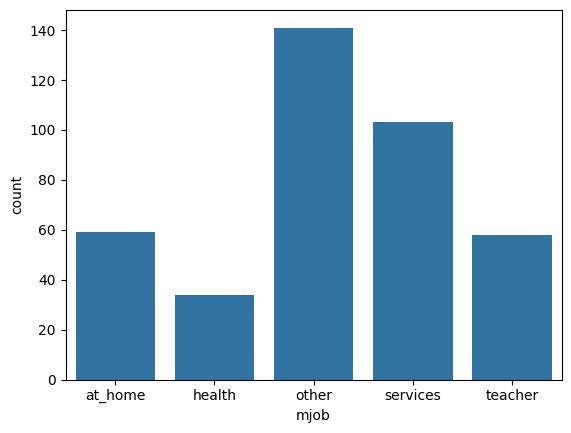

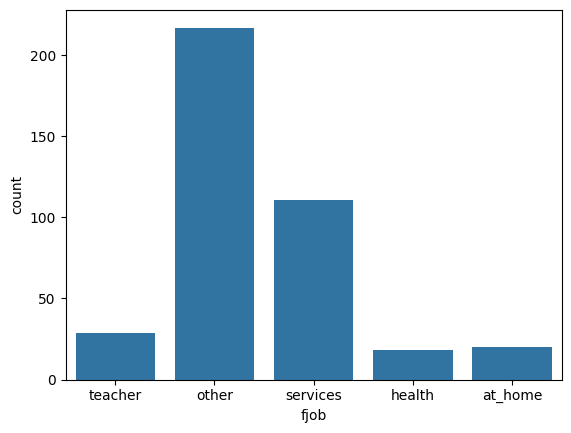

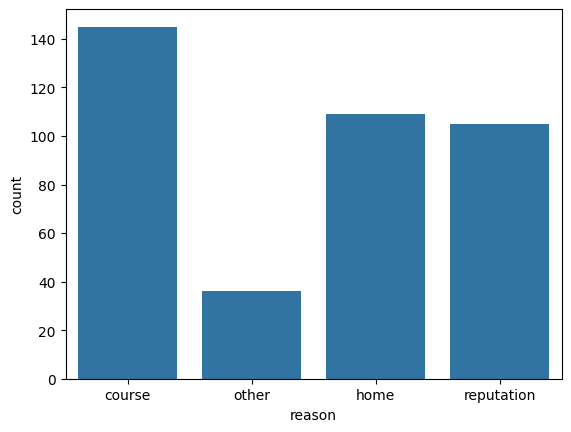

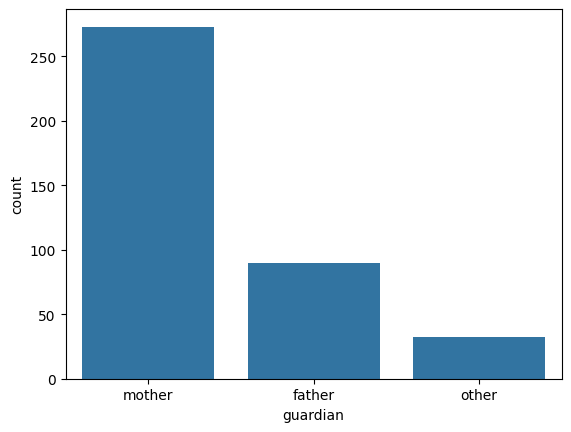

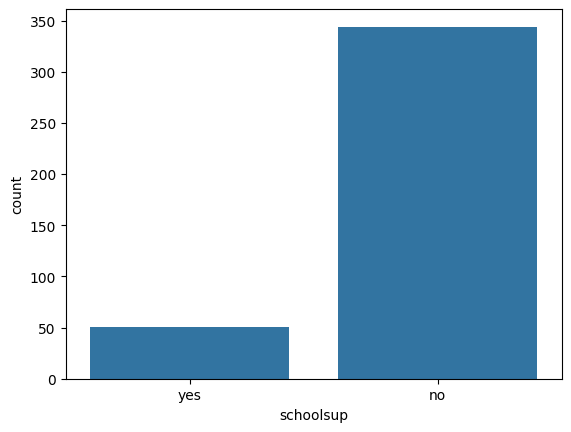

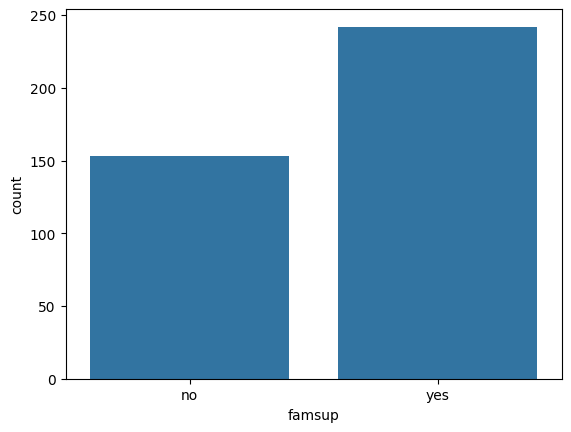

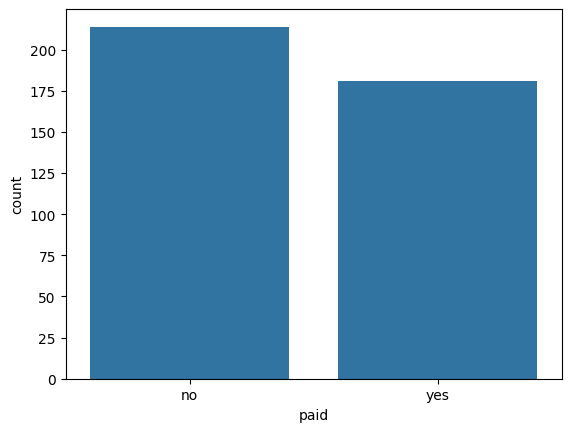

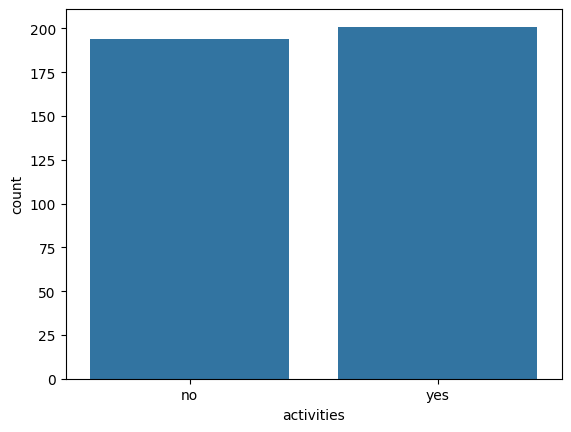

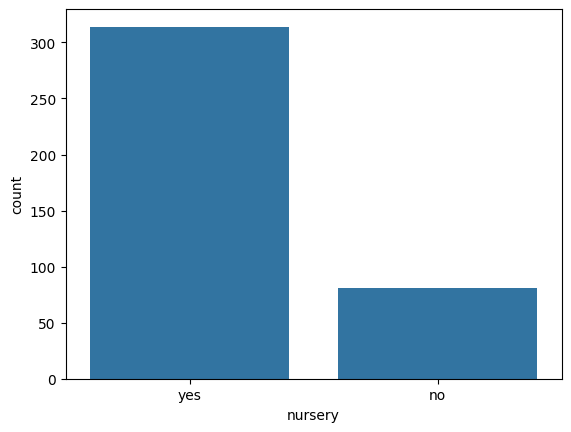

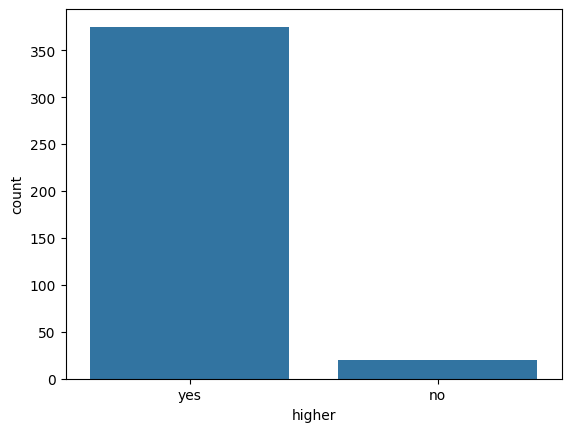

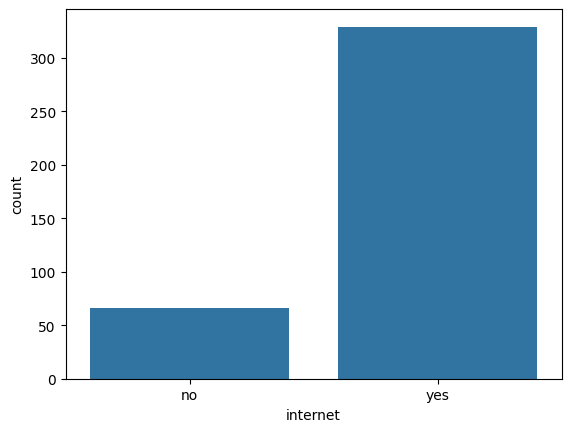

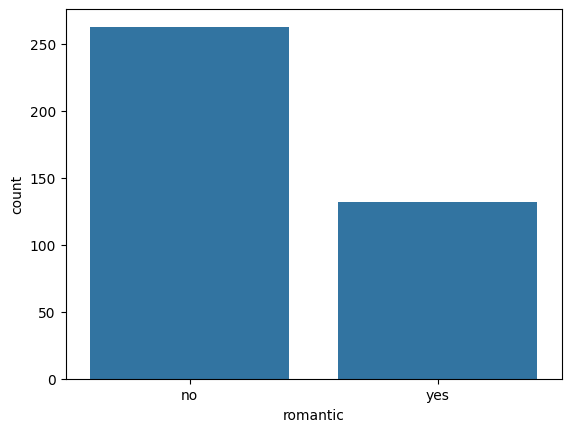

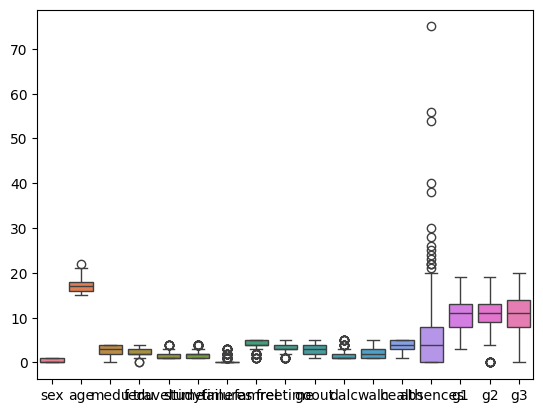

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns


for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.show()

for col in cat_cols:
    sns.countplot(x=df[col])
    plt.show()

sns.boxplot(data=df[num_cols])
plt.show()


# Task9

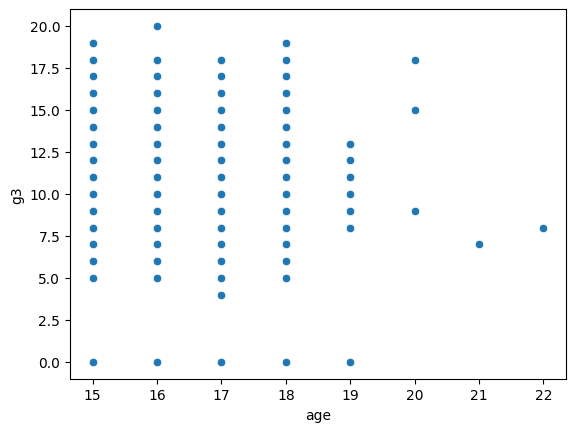

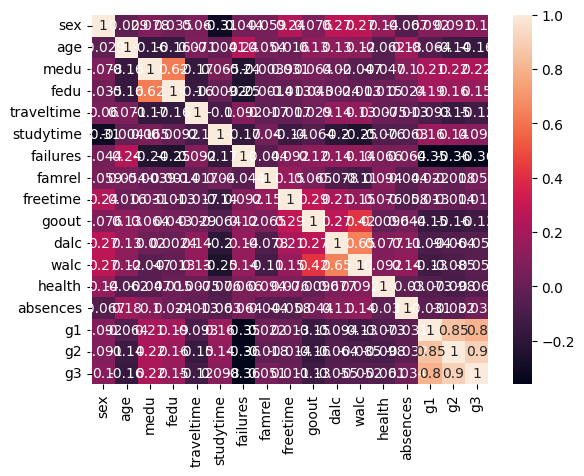

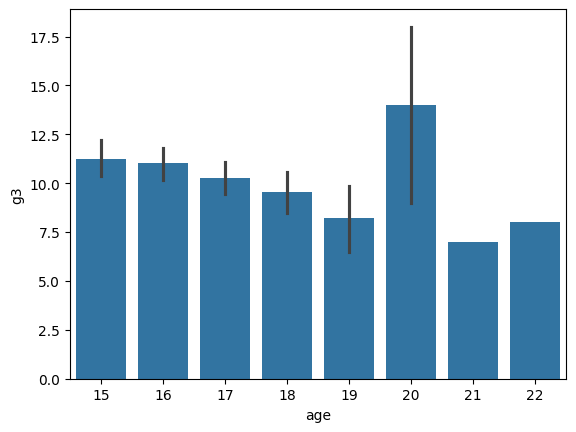

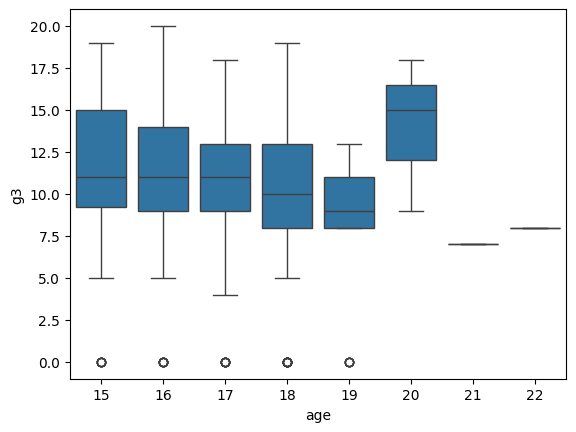

In [17]:
# Scatter
# Scatter: age vs final grade (G3)
sns.scatterplot(data=df, x="age", y=num_cols[-1])
plt.show()


# Correlation heatmap
num_cols = df.select_dtypes(include='number').columns

sns.heatmap(df[num_cols].corr(), annot=True)
plt.show()


# Bar plot
# Average final grade by gender
sns.barplot(data=df, x="age", y=num_cols[-1])
plt.show()


# Box plot
# Distribution of final grade based on study time
sns.boxplot(data=df, x="age", y=num_cols[-1])
plt.show()



# Task10

1. Higher fare passengers had better survival chances.
2. Females survived more than males.
3. Younger passengers survived more.
4. Fare has strong outliers.
5. Strong correlation between class and survival.
sd

d
d
d
d
d
